In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('../data/processed/events_enriched.csv')

## Key Findings

| Metric | Value | Notes |
|---|---|---|
| View → Cart rate | ~3% | Across categories with 1,000+ views |
| Cart → Purchase rate | ~37% | Excluding categories with 0 cart adds |
| View → Cart range | 0.05% – 14.3% | Bottom vs top category (excluding 1-cart-add outliers) |
| Category spread | ~30x | Top categories convert at nearly 30x the rate of bottom categories |
| View → Cart (out of stock) | 1.7% | Items marked available=0 |
| View → Cart (in stock) | 4.5% | Items marked available=1 |
| Out-of-stock view share | 60% | 1.4M of 2.4M total views are on unavailable items |
| Bottom 20% category view share | 9% | Low-converting categories hold a proportional share of traffic |
| Cart abandonment categories | 50 of 194 (26%) | Above-avg view→cart but below-avg cart→purchase |
| Cart abandonment view share | 24% | Proportional to category count — spread evenly across traffic |

**Data quality note:** 3 categories show `cart_to_purchase` rates ≥ 1.0 (rates of 1.0, 1.0, and 2.0). This is a low sample size artifact — each had only 1 cart add, making their rates statistically meaningless. Kept in the dataset but excluded from interpretation.

**Availability insight:** Users spend the majority of browse time on out-of-stock items, which convert at less than half the rate of in-stock items. This is a direct, actionable explanation for the low overall view→cart rate.

**Cart abandonment insight:** 26% of categories show high browse interest but below-average cart completion. These categories have a checkout confidence problem (users engage but don't commit), not a discovery problem. Fix: improve product info, reviews, and return policy visibility in these categories.

# Funneling by Parent Category

In [2]:
df.columns

Index(['itemid', 'categoryid', 'parentid', 'available', 'timestamp',
       'visitorid', 'event', 'transactionid'],
      dtype='object')

In [23]:
category_funnel = df.groupby(['parentid', 'event']).size().unstack(fill_value= 0 )
category_funnel.index = category_funnel.index.astype(int)

view = category_funnel['view']
addtocart = category_funnel['addtocart']
transaction = category_funnel['transaction']

category_funnel['view_to_cart'] = category_funnel['view_to_cart'] = addtocart / view.replace(0, np.nan)
category_funnel['cart_to_purchases'] = category_funnel['transaction'] / category_funnel['addtocart'].replace(0, np.nan)

category_funnel.head()


event,addtocart,transaction,view,view_to_cart,cart_to_purchases
parentid,,,,,
8,0,0,390,0.000000,NaN
9,57,26,3718,0.015331,0.456140
14,547,179,25247,0.021666,0.327239
19,0,0,11,0.000000,NaN
20,658,307,28697,0.022929,0.466565


In [24]:
filtered_category_funnel = category_funnel[category_funnel['view'] >= 1000]
print(f'{filtered_category_funnel['view_to_cart'].describe()}')
print(f'Cart to purchases mean: {filtered_category_funnel['cart_to_purchases'].mean().round(4)}')

count    194.000000
mean       0.030229
std        0.021858
min        0.000000
25%        0.018189
50%        0.027276
75%        0.035798
max        0.142571
Name: view_to_cart, dtype: float64
Cart to purchases mean: 0.3667


<Axes: xlabel='view_to_cart', ylabel='cart_to_purchases'>

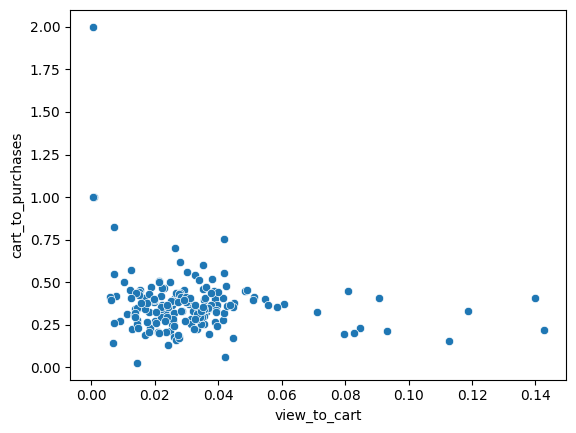

In [25]:
sns.scatterplot(x= filtered_category_funnel['view_to_cart'], y = filtered_category_funnel['cart_to_purchases'])

In [26]:
print(f'Why are there outliers greater than 1? \n')
print(f'{filtered_category_funnel[filtered_category_funnel['cart_to_purchases'] >= 1]}')

Why are there outliers greater than 1? 

event     addtocart  transaction  view  view_to_cart  cart_to_purchases
parentid                                                               
395               1            2  2205      0.000454                2.0
1453              1            1  1005      0.000995                1.0
1550              1            1  1713      0.000584                1.0


In [37]:
sorted_categories_df = filtered_category_funnel.sort_values('view_to_cart', ascending= True)
sorted_categories_df[sorted_categories_df['addtocart'] != 0]

event,addtocart,transaction,view,view_to_cart,cart_to_purchases
parentid,,,,,
395,1,2,2205,0.000454,2.000000
1550,1,1,1713,0.000584,1.000000
1453,1,1,1005,0.000995,1.000000
768,17,7,2907,0.005848,0.411765
1034,28,11,4429,0.006322,0.392857
...,...,...,...,...,...
896,122,26,1310,0.093130,0.213115
1214,248,39,2202,0.112625,0.157258
402,734,244,6180,0.118770,0.332425


# Availability 

In [45]:
df['available'] = df['available'].astype("Int64")
df['available'].value_counts()

available
0    1467863
1    1032653
Name: count, dtype: Int64

In [46]:
availability_df = df.groupby(['available', 'event']).size().unstack(fill_value= 0)
availability_df

event,addtocart,transaction,view
available,,,
0,24343,8198,1435322
1,44156,13784,974713


In [52]:
print(f'Out of Stock view --> cart rate: {round(24343 / 1435322, 4)}')
print(f'In Stock view --> cart rate: {round(44156 / 974713, 4)}')

Out of Stock view --> cart rate: 0.017
In Stock view --> cart rate: 0.0453


# Category Concentration Analysis

In [62]:
bottom_20 = filtered_category_funnel.sort_values('view_to_cart', ascending= True).iloc[:int(len(filtered_category_funnel) * .2)]
bottom_20.head(10)

event,addtocart,transaction,view,view_to_cart,cart_to_purchases
parentid,,,,,
1259,0,0,3909,0.000000,NaN
362,0,0,7040,0.000000,NaN
1658,0,0,2060,0.000000,NaN
214,0,0,1133,0.000000,NaN
418,0,0,4509,0.000000,NaN
1687,0,0,1145,0.000000,NaN
903,0,0,1513,0.000000,NaN
1009,0,1,2333,0.000000,NaN
485,0,0,6038,0.000000,NaN


In [61]:
bottom_20_views = bottom_20['view'].sum()
total_views = filtered_category_funnel['view'].sum()
print(f"Bottom Views make up {round(bottom_20_views / total_views, 4)} of all views")

Bottom Views make up 0.0925 of all views


In [69]:
vtc_mean = filtered_category_funnel['view_to_cart'].mean()
ctp_mean = filtered_category_funnel['cart_to_purchases'].mean()

high_vtc = filtered_category_funnel['view_to_cart'] > vtc_mean
low_ctp = filtered_category_funnel['cart_to_purchases'] < ctp_mean

cart_abandonment_df = filtered_category_funnel[high_vtc & low_ctp]
cart_abandonment_df.head()

event,addtocart,transaction,view,view_to_cart,cart_to_purchases
parentid,,,,,
61,357,83,4213,0.084738,0.232493
110,201,41,2428,0.082784,0.203980
114,147,48,4164,0.035303,0.326531
125,460,104,13758,0.033435,0.226087
138,50,14,1205,0.041494,0.280000


In [71]:
abandon_views = cart_abandonment_df['view'].sum()
filtered_category_funnel_views = filtered_category_funnel['view'].sum()
print(f'Cart abandonment categories account for: {round(abandon_views / filtered_category_funnel_views, 4)} of total views')

Cart abandonment categories account for: 0.2368 of total views
